# MODEL EVALUATION

## 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import re
import pickle
import joblib
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    brier_score_loss
)

from sklearn.calibration import calibration_curve

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 2. Recreate the Column-Cleaning Helper

The saved model package includes a reference to the `clean_column_names` function that was used during training. `pickle` stores functions **by reference**, not by value, so when this notebook is opened in a fresh kernel that function has to exist under the same name *before* we try to load the pickle file otherwise `pickle.load` fails with `AttributeError: module '__main__' has no attribute 'clean_column_names'` (which is what was happening before).

In [2]:
def clean_column_names(df):
    df = df.copy()
    df.columns = [
        re.sub(r'[^A-Za-z0-9_]', '_', col)
        for col in df.columns
    ]
    return df

## 3. Load the Saved Model Package

In [3]:

# Load model
OUTPUT_DIR = Path("output")

MODEL_PATH = OUTPUT_DIR / "final_credit_risk_model.pkl"

final_model_package = joblib.load(MODEL_PATH)

final_model = final_model_package["model"]
final_calibrator = final_model_package["calibrator"]

FINAL_THRESHOLD = final_model_package["threshold"]

TRAINING_COLUMNS = final_model_package["training_columns"]
CATEGORICAL_COLUMNS = final_model_package["categorical_columns"]

print("Expected features:", len(TRAINING_COLUMNS))
print("Categorical columns:", len(CATEGORICAL_COLUMNS))

Expected features: 842
Categorical columns: 0


In [4]:
# Load Training Data
train_data = pd.read_parquet(
    OUTPUT_DIR / "train_feature_engineered.parquet"
)

print("Data shape:", train_data.shape)
print("TARGET present:", "TARGET" in train_data.columns)

Data shape: (307511, 757)
TARGET present: True


## 4. Separate features and target

Separate the dataset into the input features (X) and the target variable (y) 

In [5]:

# Separate features and target
X = train_data.drop(
    columns=["TARGET", "SK_ID_CURR"],
    errors="ignore"
).copy()

y = train_data["TARGET"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (307511, 755)
y shape: (307511,)


## 5. Train / Validation split

In [6]:

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)

X_train: (246008, 755)
X_valid: (61503, 755)


## 6. Compare the data against the saved model schema

In [7]:


current_columns = set(X_valid.columns)
expected_columns = set(TRAINING_COLUMNS)

missing_columns = expected_columns - current_columns
extra_columns = current_columns - expected_columns

print("MODEL EXPECTS:", len(TRAINING_COLUMNS))
print("CURRENT VALIDATION FEATURES:", X_valid.shape[1])

print("\nMissing model columns:", len(missing_columns))
print("Extra validation columns:", len(extra_columns))

print("\nFirst 30 missing model columns:")
print(sorted(missing_columns)[:30])

print("\nFirst 30 extra validation columns:")
print(sorted(extra_columns)[:30])

MODEL EXPECTS: 842
CURRENT VALIDATION FEATURES: 755

Missing model columns: 191
Extra validation columns: 104

First 30 missing model columns:
['BUREAU_CREDIT_ACTIVE_BAD_DEBT_MEAN', 'BUREAU_CREDIT_CURRENCY_CURRENCY_1_MEAN', 'BUREAU_CREDIT_CURRENCY_CURRENCY_2_MEAN', 'BUREAU_CREDIT_CURRENCY_CURRENCY_3_MEAN', 'BUREAU_CREDIT_CURRENCY_CURRENCY_4_MEAN', 'BUREAU_CREDIT_TYPE_ANOTHER_TYPE_OF_LOAN_MEAN', 'BUREAU_CREDIT_TYPE_CAR_LOAN_MEAN', 'BUREAU_CREDIT_TYPE_CASH_LOAN__NON_EARMARKED__MEAN', 'BUREAU_CREDIT_TYPE_CONSUMER_CREDIT_MEAN', 'BUREAU_CREDIT_TYPE_CREDIT_CARD_MEAN', 'BUREAU_CREDIT_TYPE_INTERBANK_CREDIT_MEAN', 'BUREAU_CREDIT_TYPE_LOAN_FOR_BUSINESS_DEVELOPMENT_MEAN', 'BUREAU_CREDIT_TYPE_LOAN_FOR_PURCHASE_OF_SHARES__MARGIN_LENDING__MEAN', 'BUREAU_CREDIT_TYPE_LOAN_FOR_THE_PURCHASE_OF_EQUIPMENT_MEAN', 'BUREAU_CREDIT_TYPE_LOAN_FOR_WORKING_CAPITAL_REPLENISHMENT_MEAN', 'BUREAU_CREDIT_TYPE_MOBILE_OPERATOR_LOAN_MEAN', 'BUREAU_CREDIT_TYPE_REAL_ESTATE_LOAN_MEAN', 'BUREAU_CREDIT_TYPE_UNKNOWN_TYPE_OF_LO

## 7. Identify categorical columns

In [8]:


categorical_columns = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical columns:", len(categorical_columns))
print(categorical_columns)

Categorical columns: 16
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


In [9]:
# Handle missing values in categorical columns


X_train_encoded = X_train.copy()
X_valid_encoded = X_valid.copy()

for col in categorical_columns:
    X_train_encoded[col] = (
        X_train_encoded[col]
        .astype("object")
        .fillna("Missing")
    )

    X_valid_encoded[col] = (
        X_valid_encoded[col]
        .astype("object")
        .fillna("Missing")
    )

In [10]:
# Encode categorical columns

X_train_encoded = pd.get_dummies(
    X_train_encoded,
    columns=categorical_columns,
    dummy_na=False
)

X_valid_encoded = pd.get_dummies(
    X_valid_encoded,
    columns=categorical_columns,
    dummy_na=False
)

#####  Align to saved model schema

Align the feature columns of the validation data with the exact feature schema used when the model was trained.

In [11]:



X_valid_model = X_valid_encoded.reindex(
    columns=TRAINING_COLUMNS,
    fill_value=0
)

print("\nVALIDATION DATA READY")
print("=" * 80)

print("Validation shape:", X_valid_model.shape)
print("Expected features:", len(TRAINING_COLUMNS))

print(
    "Exact column match:",
    list(X_valid_model.columns) == list(TRAINING_COLUMNS)
)


VALIDATION DATA READY
Validation shape: (61503, 842)
Expected features: 842
Exact column match: True


In [12]:
# Check model Input


print("Total missing values:", X_valid_model.isna().sum().sum())

print(
    "Non-numeric columns:",
    X_valid_model.select_dtypes(
        exclude=np.number
    ).columns.tolist()
)

Total missing values: 0
Non-numeric columns: ['CODE_GENDER_F', 'CODE_GENDER_M', 'CODE_GENDER_XNA', 'FLAG_OWN_CAR_N', 'FLAG_OWN_CAR_Y', 'FLAG_OWN_REALTY_N', 'FLAG_OWN_REALTY_Y', 'NAME_TYPE_SUITE_Children', 'NAME_TYPE_SUITE_Family', 'NAME_TYPE_SUITE_Missing', 'NAME_TYPE_SUITE_Other_A', 'NAME_TYPE_SUITE_Other_B', 'NAME_TYPE_SUITE_Unaccompanied', 'NAME_INCOME_TYPE_Businessman', 'NAME_INCOME_TYPE_Pensioner', 'NAME_INCOME_TYPE_Student', 'NAME_INCOME_TYPE_Unemployed', 'NAME_INCOME_TYPE_Working', 'NAME_FAMILY_STATUS_Married', 'NAME_FAMILY_STATUS_Separated', 'NAME_FAMILY_STATUS_Widow', 'OCCUPATION_TYPE_Accountants', 'OCCUPATION_TYPE_Drivers', 'OCCUPATION_TYPE_Laborers', 'OCCUPATION_TYPE_Managers', 'OCCUPATION_TYPE_Missing', 'OCCUPATION_TYPE_Secretaries', 'WEEKDAY_APPR_PROCESS_START_FRIDAY', 'WEEKDAY_APPR_PROCESS_START_MONDAY', 'WEEKDAY_APPR_PROCESS_START_SATURDAY', 'WEEKDAY_APPR_PROCESS_START_SUNDAY', 'WEEKDAY_APPR_PROCESS_START_THURSDAY', 'WEEKDAY_APPR_PROCESS_START_TUESDAY', 'WEEKDAY_APPR_PRO

In [13]:
# Convert encoded features to numeric


X_valid_model = X_valid_model.astype(np.float32)

print("DATA TYPE CHECK")
print("=" * 80)

print(
    "Non-numeric columns:",
    X_valid_model.select_dtypes(exclude=np.number).columns.tolist()
)

print("\nData types:")
print(X_valid_model.dtypes.value_counts())

print("\nMissing values:")
print(X_valid_model.isna().sum().sum())

print("\nShape:")
print(X_valid_model.shape)

DATA TYPE CHECK
Non-numeric columns: []

Data types:
float32    842
Name: count, dtype: int64

Missing values:
0

Shape:
(61503, 842)


## 8. Catboost raw validation predictions

In [14]:


raw_valid_prob = final_model.predict_proba(
    X_valid_model
)[:, 1]

print("RAW PREDICTIONS GENERATED")
print("=" * 80)

print("Number of predictions:", len(raw_valid_prob))
print("Minimum probability:", raw_valid_prob.min())
print("Maximum probability:", raw_valid_prob.max())
print("Mean probability:", raw_valid_prob.mean())

RAW PREDICTIONS GENERATED
Number of predictions: 61503
Minimum probability: 0.012205595626399255
Maximum probability: 0.9226669033150144
Mean probability: 0.23793329857365753


## Raw Predictions

The purpose of this code is to use the **final CatBoost model** to calculate the **probability of default for each applicant** in the validation dataset. The `[:, 1]` selects the probability that an applicant belongs to **class 1 (defaulter)**. At this stage, the model is only generating probabilities; the **0.14 decision threshold has not yet been applied**.

### Interpretation

- **61,503 predictions:** The model generated a default probability for all 61,503 validation applicants.
- **Minimum probability = 1.22%:** The applicant with the lowest predicted risk had about a 1.2% chance of default.
- **Maximum probability = 92.27%:** The highest-risk applicant had about a 92.3% predicted chance of default.
- **Mean probability = 23.79%:** On average, the model predicted a 23.8% probability of default across the validation applicants.

Overall, the model produces a **range of risk probabilities**, from very low to very high. These probabilities are then used with the **final 0.14 threshold** to classify applicants as either **defaulters or non-defaulters**.

## 9. Calibrate validation probabilities

In [15]:


calibrated_valid_prob = final_calibrator.predict(
    raw_valid_prob
)

print("CALIBRATED PREDICTIONS GENERATED")
print("=" * 80)

print("Number of predictions:", len(calibrated_valid_prob))
print("Minimum probability:", calibrated_valid_prob.min())
print("Maximum probability:", calibrated_valid_prob.max())
print("Mean probability:", calibrated_valid_prob.mean())

CALIBRATED PREDICTIONS GENERATED
Number of predictions: 61503
Minimum probability: 0.0
Maximum probability: 1.0
Mean probability: 0.07459749230109276


## Calibrated Predictions

This step follows the raw predictions because the raw probabilities produced by the CatBoost model may not accurately represent the **actual likelihood of default**. The model first gives its raw probability estimates, and the **Isotonic calibration model** then adjusts those probabilities so they better reflect the observed default rates. These calibrated probabilities are the ones used before applying the final **0.14 decision threshold**.

### Interpretation

- **61,503 predictions:** The calibrator adjusted the probability for every applicant in the validation dataset.
- **Minimum probability = 0.00:** Some applicants were assigned an extremely low predicted probability of default.
- **Maximum probability = 1.00:** Some applicants were assigned a very high predicted probability of default.
- **Mean probability = 7.46%:** After calibration, the average predicted probability of default is about **7.5%**, which is much closer to the dataset's actual default rate of about **8%**.

Overall, calibration has brought the model's probabilities closer to the **realistic default rate in the data**. These calibrated probabilities are then compared with the **0.14 threshold** to make the final credit-risk decision.

## 10. Apply saved decision Thresholds

In [16]:

valid_predictions = (
    calibrated_valid_prob >= FINAL_THRESHOLD
).astype(int)

print("FINAL VALIDATION PREDICTIONS")
print("=" * 80)

print("Threshold:", FINAL_THRESHOLD)

print("\nPrediction distribution:")
print(
    pd.Series(valid_predictions).value_counts()
)

print("\nPrediction proportions:")
print(
    pd.Series(valid_predictions)
    .value_counts(normalize=True)
)

FINAL VALIDATION PREDICTIONS
Threshold: 0.14

Prediction distribution:
0    53760
1     7743
Name: count, dtype: int64

Prediction proportions:
0    0.874104
1    0.125896
Name: proportion, dtype: float64


## Final Validation Predictions

This code takes the **calibrated default probabilities** and applies the final **0.14 decision threshold**. Applicants with a predicted probability of default **greater than or equal to 0.14** are classified as **1 (defaulter/high risk)**, while those below 0.14 are classified as **0 (non-defaulter/low risk)**. The code then shows how many applicants fall into each class and their percentage of the validation dataset.

### Interpretation

- **Class 0: 53,760 applicants (87.41%)** - These applicants were classified as **non-defaulters/low risk** because their calibrated probability was below 0.14.
- **Class 1: 7,743 applicants (12.59%)** - These applicants were classified as **defaulters/high risk** because their calibrated probability was 0.14 or higher.

Overall, the model flags **12.59% of applicants as high risk** at the 0.14 threshold. This threshold was selected because it produced the **lowest business cost of 19,380**, while giving a defaulter recall of about **44.3%**.

## 11. Final validation Metrics

In [17]:


accuracy = accuracy_score(
    y_valid,
    valid_predictions
)

precision = precision_score(
    y_valid,
    valid_predictions,
    zero_division=0
)

recall = recall_score(
    y_valid,
    valid_predictions,
    zero_division=0
)

f1 = f1_score(
    y_valid,
    valid_predictions,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_valid,
    calibrated_valid_prob
)

average_precision = average_precision_score(
    y_valid,
    calibrated_valid_prob
)

brier = brier_score_loss(
    y_valid,
    calibrated_valid_prob
)

print("FINAL MODEL VALIDATION RESULTS")
print("=" * 80)

print(f"Accuracy:          {accuracy:.4f}")
print(f"Precision:         {precision:.4f}")
print(f"Recall:            {recall:.4f}")
print(f"F1-score:          {f1:.4f}")
print(f"ROC-AUC:           {roc_auc:.4f}")
print(f"Average Precision: {average_precision:.4f}")
print(f"Brier Score:       {brier:.4f}")

FINAL MODEL VALIDATION RESULTS
Accuracy:          0.8649
Precision:         0.2839
Recall:            0.4427
F1-score:          0.3459
ROC-AUC:           0.7838
Average Precision: 0.2751
Brier Score:       0.0659


## Final Model Validation Results

The final model was evaluated on the validation dataset using the calibrated probabilities and the **0.14 decision threshold**. These metrics show how well the model identifies defaulters, separates high-risk from low-risk applicants, and produces reliable probability estimates.

### Interpretation

- **Accuracy = 86.49%:** The model correctly classified about **86 out of every 100 applicants** overall.
- **Precision = 28.39%:** Of the applicants the model flagged as high risk, about **28% were actually defaulters**. This is relatively low, meaning the model produces a number of false alarms.
- **Recall = 44.27%:** The model correctly identified about **44% of all actual defaulters**. This is important because missing a defaulter is more costly in this project.
- **F1-score = 34.59%:** This provides a balance between precision and recall. The score reflects the trade-off between catching defaulters and avoiding false alarms.
- **ROC-AUC = 78.38%:** The model has a **good ability to distinguish between defaulters and non-defaulters**. A value of 0.5 would represent random performance, while 0.7838 shows meaningful predictive ability.
- **Average Precision = 27.51%:** This measures how well the model identifies the minority class (defaulters) across different thresholds. It shows that the model performs considerably better than random ranking, although there is still room for improvement.
- **Brier Score = 0.0659:** This measures how close the predicted probabilities are to the actual outcomes. A lower score is better, and this relatively low value indicates that the calibrated probabilities are reasonably reliable.

### Overall Interpretation

The model provides **good overall discrimination and reasonably calibrated probabilities**, but its precision is relatively low. This is an expected trade-off because the model uses a **0.14 threshold and a 5:1 cost assumption**, prioritizing the detection of defaulters because missing a defaulter is considered five times more costly than incorrectly flagging a non-defaulter.

## 12. Classification report

In [18]:


print(
    classification_report(
        y_valid,
        valid_predictions,
        target_names=[
            "Non-Defaulter",
            "Defaulter"
        ],
        zero_division=0
    )
)

               precision    recall  f1-score   support

Non-Defaulter       0.95      0.90      0.92     56538
    Defaulter       0.28      0.44      0.35      4965

     accuracy                           0.86     61503
    macro avg       0.62      0.67      0.64     61503
 weighted avg       0.89      0.86      0.88     61503



## Classification Report Interpretation

The classification report shows how the final model performs separately for **non-defaulters and defaulters**.

- **Non-Defaulters:** The model performs strongly, with **95% precision** and **90% recall**. This means most applicants classified as non-defaulters were actually non-defaulters, and the model correctly identified about 90% of all actual non-defaulters.
- **Defaulters:** The model has **28% precision** and **44% recall**. This means that about 44% of actual defaulters were successfully identified, but only 28% of applicants flagged as defaulters were actually defaulters. Therefore, the model catches a reasonable portion of risky applicants but also produces a significant number of false positives.
- **F1-score:** The F1-score is **0.92 for non-defaulters** and **0.35 for defaulters**, showing that the model is much stronger at identifying the majority class than the minority class.
- **Overall accuracy:** The model achieves **86% accuracy**, but accuracy alone should not be relied upon because non-defaulters make up most of the dataset.
- **Macro average:** The macro F1-score of **0.64** shows the model's average performance across both classes without giving more weight to the larger non-defaulter class.
- **Weighted average:** The weighted F1-score of **0.88** is high mainly because non-defaulters represent the majority of applicants.

### Overall

The model is **much better at identifying non-defaulters than defaulters**. However, because this is a credit-risk problem where missing a defaulter is more costly, the **44% defaulter recall** is particularly important. The lower precision reflects the deliberate decision to use the **0.14 threshold** to catch more potential defaulters and minimize the overall business cost.

## 13. Confusion Matrix

In [19]:

cm = confusion_matrix(
    y_valid,
    valid_predictions
)

tn, fp, fn, tp = cm.ravel()

print("CONFUSION MATRIX")
print("=" * 80)

print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

CONFUSION MATRIX
True Negatives:  50993
False Positives: 5545
False Negatives: 2767
True Positives:  2198


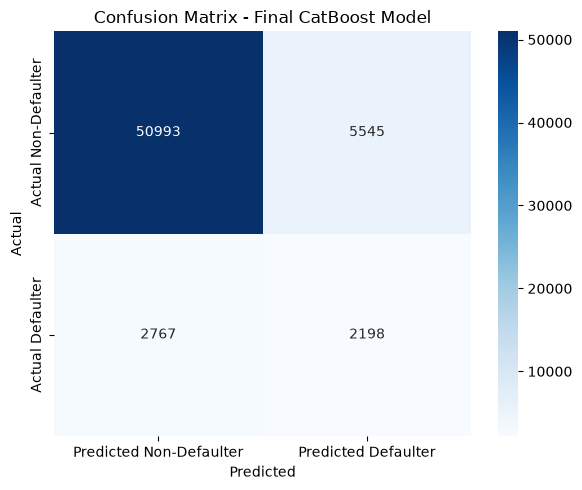

In [20]:
#Confusion matrix display


plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Predicted Non-Defaulter",
        "Predicted Defaulter"
    ],
    yticklabels=[
        "Actual Non-Defaulter",
        "Actual Defaulter"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Final CatBoost Model")
plt.tight_layout()
plt.show()

The final CatBoost model was evaluated on 61,503 validation observations using the optimized decision threshold of 0.14. The model correctly classified 50,993 non-defaulters as low-risk applicants, representing the True Negatives (TN). It incorrectly classified 5,545 non-defaulters as high-risk applicants, representing the False Positives (FP). In practice, these applicants may be unnecessarily flagged for further review or potentially face stricter lending decisions despite not actually being defaulters.

The model also incorrectly classified 2,767 actual defaulters as non-defaulters, representing the False Negatives (FN). This is considered the most costly type of error in the business scenario because the lender may approve or offer favourable credit terms to customers who are actually likely to default. Finally, the model correctly identified 2,198 actual defaulters as high-risk applicants, representing the True Positives (TP). These results demonstrate the model's ability to distinguish between low-risk and high-risk borrowers while highlighting the trade-off between identifying more potential defaulters and incorrectly flagging some non-defaulters.

#### ROC Curve

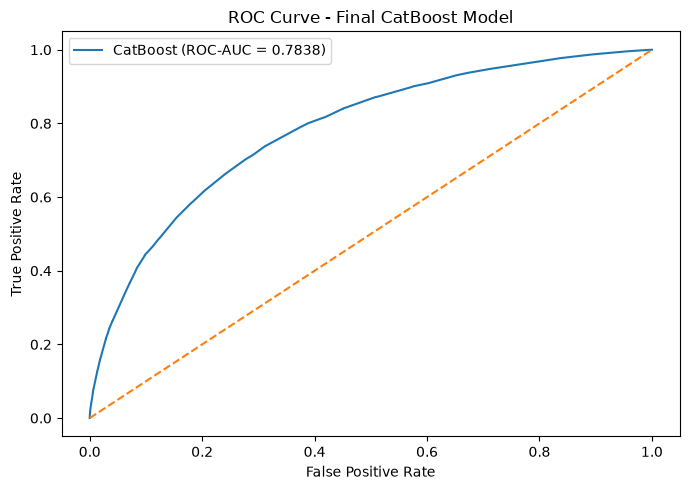

In [21]:


fpr, tpr, _ = roc_curve(
    y_valid,
    calibrated_valid_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"CatBoost (ROC-AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final CatBoost Model")
plt.legend()
plt.tight_layout()
plt.show()

The ROC curve evaluates the model's ability to distinguish between defaulters and non-defaulters across different classification thresholds. The final CatBoost model achieved an ROC-AUC of 0.7838, indicating good discriminatory ability. This means that the model can effectively rank a randomly selected defaulter as having a higher predicted risk than a randomly selected non-defaulter approximately 78.4% of the time. The ROC curve is comfortably above the diagonal reference line, which represents the performance of a model making random predictions. Therefore, the result shows that the model has a solid ability to differentiate between high-risk and low-risk applicants. Additionally, the ROC-AUC of 0.7838 is consistent with the approximately 0.784 score obtained during cross-validation, suggesting that the model's performance is relatively stable and generalizes well to the validation data.

### Precision recall curve

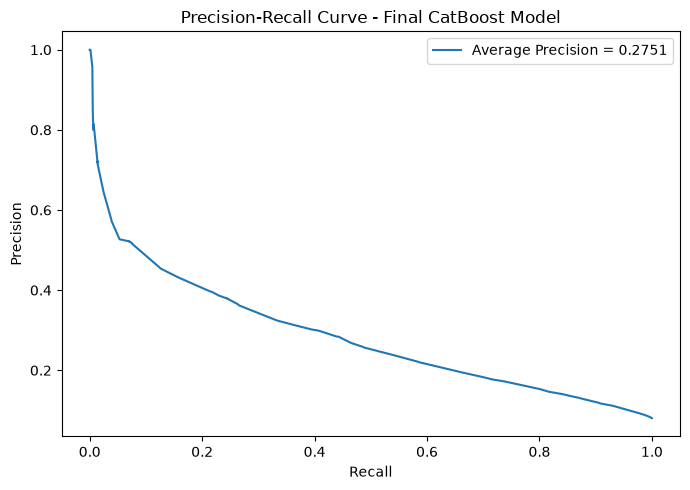

In [22]:

precision_values, recall_values, _ = precision_recall_curve(
    y_valid,
    calibrated_valid_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    recall_values,
    precision_values,
    label=f"Average Precision = {average_precision:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Final CatBoost Model")
plt.legend()
plt.tight_layout()
plt.show()

The final CatBoost model achieved an Average Precision (AP) score of 0.2751, which is close to the approximately 0.28 observed during earlier evaluation. Since the default rate is only about 8%, the model's AP is approximately 3.4 times higher than random, indicating that it has meaningful ability to identify potential defaulters.

The curve also shows a trade-off between precision and recall. As recall increases, precision decreases, particularly beyond approximately 40% recall, meaning that identifying more defaulters comes with more false positives. Overall, the model demonstrates useful performance for this imbalanced credit-risk problem while highlighting the need for an appropriate decision threshold.

### Business cost at final thresholds

In [23]:


TN, FP, FN, TP = confusion_matrix(
    y_valid,
    valid_predictions
).ravel()

FP_COST = final_model_package["false_positive_cost"]
FN_COST = final_model_package["false_negative_cost"]

total_business_cost = (
    FP * FP_COST +
    FN * FN_COST
)

print("BUSINESS COST ANALYSIS")
print("=" * 80)

print(f"False Positive Cost: {FP_COST}")
print(f"False Negative Cost: {FN_COST}")

print(f"\nFalse Positives: {FP}")
print(f"False Negatives: {FN}")

print(
    f"\nTotal Business Cost: {total_business_cost:,.2f}"
)

BUSINESS COST ANALYSIS
False Positive Cost: 1
False Negative Cost: 5

False Positives: 5545
False Negatives: 2767

Total Business Cost: 19,380.00


This code calculates the financial/business impact of the model's mistakes at the final threshold of 0.14. It first gets the four confusion-matrix values: True Negatives, False Positives, False Negatives, and True Positives. It then assigns a cost of 1 to each false positive and a higher cost of 5 to each false negative, because incorrectly approving a customer who later defaults is considered more costly than unnecessarily flagging a customer who would not have defaulted.

The model produced 5,545 false positives and 2,767 false negatives. Therefore, the total business cost is calculated as (5,545 × 1) + (2,767 × 5) = 19,380. This means that, under the assumed cost structure, the model's classification errors result in a total relative business cost of 19,380 cost units on the 61,503 validation applications. The important point is that false negatives contribute most of the cost, because each false negative is five times more expensive than a false positive. This is why threshold optimization was important in selecting 0.14 as the final threshold.

#### Threshold Business cost analysis

In [24]:


thresholds = np.arange(0.05, 0.51, 0.01)

threshold_results = []

FP_COST = final_model_package["false_positive_cost"]
FN_COST = final_model_package["false_negative_cost"]

for threshold in thresholds:

    predictions = (
        calibrated_valid_prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_valid,
        predictions
    ).ravel()

    total_cost = (
        fp * FP_COST +
        fn * FN_COST
    )

    threshold_results.append({
        "threshold": threshold,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
        "true_negatives": tn,
        "precision": precision_score(
            y_valid,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            y_valid,
            predictions,
            zero_division=0
        ),
        "f1_score": f1_score(
            y_valid,
            predictions,
            zero_division=0
        ),
        "total_cost": total_cost
    })

threshold_results_df = pd.DataFrame(
    threshold_results
)

print("THRESHOLD BUSINESS COST ANALYSIS")
print("=" * 100)

print(
    threshold_results_df[
        [
            "threshold",
            "false_positives",
            "false_negatives",
            "precision",
            "recall",
            "f1_score",
            "total_cost"
        ]
    ].to_string(index=False)
)

THRESHOLD BUSINESS COST ANALYSIS
 threshold  false_positives  false_negatives  precision   recall  f1_score  total_cost
      0.05            23382              921   0.147451 0.814502  0.249699       27987
      0.06            17608             1302   0.172206 0.737764  0.279235       24118
      0.07            17608             1302   0.172206 0.737764  0.279235       24118
      0.08            15707             1474   0.181842 0.703122  0.288954       23077
      0.09            11530             1902   0.209895 0.616918  0.313222       21040
      0.10            11530             1902   0.209895 0.616918  0.313222       21040
      0.11            10305             2056   0.220145 0.585901  0.320040       20585
      0.12            10249             2060   0.220845 0.585096  0.320658       20549
      0.13             6287             2659   0.268358 0.464451  0.340168       19582
      0.14             5545             2767   0.283869 0.442699  0.345924       19380
      0.15

This analysis tests different decision thresholds from 0.05 to 0.50 to determine which threshold gives the lowest business cost. For every threshold, the model classifies an applicant as a defaulter when their calibrated probability is equal to or above that threshold. The code then calculates the resulting false positives, false negatives, precision, recall, F1-score, and total business cost.

The results show a clear trade-off. At a low threshold such as 0.05, the model identifies many more potential defaulters, giving a high recall of 81.5%, but it also produces 23,382 false positives, resulting in a high cost of 27,987. As the threshold increases, false positives decrease but false negatives increase. The lowest business cost occurs at a threshold of 0.14, with a total cost of 19,380, 5,545 false positives, and 2,767 false negatives. Therefore, 0.14 was selected as the optimal threshold because it minimizes the defined business cost while maintaining a reasonable balance between identifying defaulters and avoiding unnecessary rejection or review of non-defaulters.

### find optimal Business cost threshold

In [25]:


best_threshold_row = threshold_results_df.loc[
    threshold_results_df["total_cost"].idxmin()
]

optimal_threshold = best_threshold_row["threshold"]
optimal_cost = best_threshold_row["total_cost"]

print("OPTIMAL BUSINESS-COST THRESHOLD")
print("=" * 80)

print(f"Optimal threshold: {optimal_threshold:.2f}")
print(f"Minimum total cost: {optimal_cost:,.2f}")

print(
    f"False positives: "
    f"{int(best_threshold_row['false_positives']):,}"
)

print(
    f"False negatives: "
    f"{int(best_threshold_row['false_negatives']):,}"
)

print(
    f"Precision: "
    f"{best_threshold_row['precision']:.4f}"
)

print(
    f"Recall: "
    f"{best_threshold_row['recall']:.4f}"
)

print(
    f"F1-score: "
    f"{best_threshold_row['f1_score']:.4f}"
)

OPTIMAL BUSINESS-COST THRESHOLD
Optimal threshold: 0.14
Minimum total cost: 19,380.00
False positives: 5,545
False negatives: 2,767
Precision: 0.2839
Recall: 0.4427
F1-score: 0.3459


The analysis identified 0.14 as the optimal decision threshold, producing the lowest total business cost of 19,380. At this threshold, the model generated 5,545 false positives and 2,767 false negatives on the validation set.

The model achieves a precision of 28.39%, meaning about 28% of applicants predicted as defaulters were actually defaulters, while the recall of 44.27% means the model successfully identified about 44% of all actual defaulters. The F1-score of 34.59% reflects the balance between precision and recall. Overall, 0.14 was selected because it provides the most cost-effective balance under the assumption that a false negative is five times more costly than a false positive.

### Comparison between Current vs optimal thresholds

In [26]:


current_threshold = FINAL_THRESHOLD

current_row = threshold_results_df[
    threshold_results_df["threshold"].round(2)
    == round(current_threshold, 2)
].iloc[0]

print("CURRENT VS OPTIMAL THRESHOLD")
print("=" * 80)

print(f"Current threshold:  {current_threshold:.2f}")
print(f"Current cost:       {current_row['total_cost']:,.2f}")

print()

print(f"Optimal threshold:  {optimal_threshold:.2f}")
print(f"Optimal cost:       {optimal_cost:,.2f}")

print()

print(
    "Cost reduction:",
    f"{current_row['total_cost'] - optimal_cost:,.2f}"
)

CURRENT VS OPTIMAL THRESHOLD
Current threshold:  0.14
Current cost:       19,380.00

Optimal threshold:  0.14
Optimal cost:       19,380.00

Cost reduction: 0.00


The current threshold of 0.14 is already the optimal threshold, as both the current and optimal thresholds produce the same business cost of 19,380. This confirms that the threshold currently used by the final model is consistent with the threshold identified through the business-cost analysis.

There is therefore no additional cost reduction (0.00) from changing the threshold. This confirms that 0.14 should remain the final decision threshold, given the assumed business costs of false positives and false negatives.

### Top 10 lowest cost thresholds

In [27]:


top_thresholds = (
    threshold_results_df
    .sort_values("total_cost")
    .head(10)
)

print("TOP 10 LOWEST-COST THRESHOLDS")
print("=" * 100)

print(
    top_thresholds[
        [
            "threshold",
            "false_positives",
            "false_negatives",
            "precision",
            "recall",
            "f1_score",
            "total_cost"
        ]
    ].to_string(index=False)
)

TOP 10 LOWEST-COST THRESHOLDS
 threshold  false_positives  false_negatives  precision   recall  f1_score  total_cost
      0.14             5545             2767   0.283869 0.442699  0.345924       19380
      0.15             4805             2928   0.297720 0.410272  0.345050       19445
      0.16             4805             2928   0.297720 0.410272  0.345050       19445
      0.17             4732             2946   0.299067 0.406647  0.344657       19462
      0.18             4521             3008   0.302099 0.394159  0.342043       19561
      0.13             6287             2659   0.268358 0.464451  0.340168       19582
      0.19             4033             3141   0.311422 0.367372  0.337091       19738
      0.20             3447             3310   0.324383 0.333333  0.328797       19997
      0.21             3447             3311   0.324250 0.333132  0.328631       20002
      0.12            10249             2060   0.220845 0.585096  0.320658       20549


The table shows the 10 thresholds that produce the lowest business costs. The best-performing threshold is 0.14, with the lowest total cost of 19,380, followed by 0.15 and 0.16, both with a cost of 19,445. This shows that the model performs relatively consistently around the selected threshold, rather than depending on one isolated value.

At 0.14, the model achieves 44.27% recall, identifying more actual defaulters than the 0.15 threshold, while keeping the business cost at its minimum. Although the 0.15 threshold has slightly higher precision (29.77%), it misses more actual defaulters, increasing the number of false negatives from 2,767 to 2,928. Therefore, 0.14 remains the preferred threshold because it provides the lowest overall business cost and a slightly better F1-score (34.59%).

### Business cost by threshold

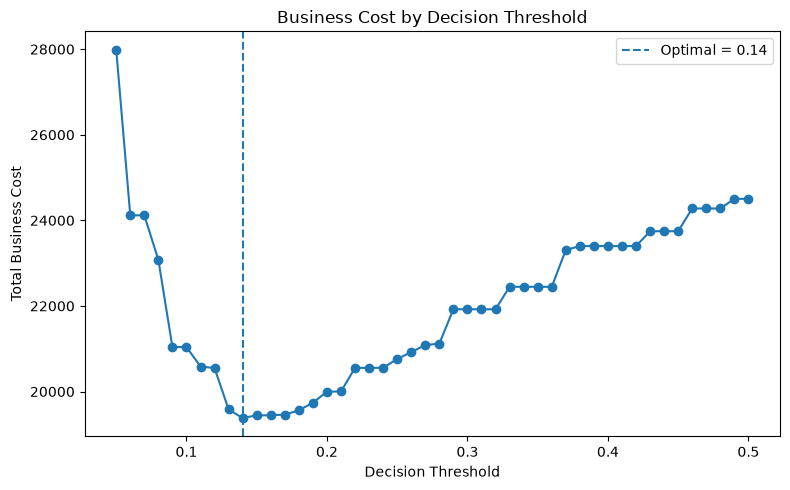

In [28]:


plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["total_cost"],
    marker="o"
)

plt.axvline(
    optimal_threshold,
    linestyle="--",
    label=f"Optimal = {optimal_threshold:.2f}"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Total Business Cost")
plt.title("Business Cost by Decision Threshold")
plt.legend()
plt.tight_layout()
plt.show()

The Business Cost by Decision Threshold analysis evaluates how the model's total business cost changes as the decision threshold is varied. On the full validation set, the lowest cost occurs at a threshold of 0.14, with a total cost of 19,380. This confirms that the selected threshold performs well beyond the smaller calibration sample and provides evidence that the threshold is not simply overfitted to that hold-out data.

The results also show that the cost is relatively stable around 0.10-0.20, meaning small changes within this range do not dramatically affect the overall business cost. However, thresholds below 0.10 generate many more false positives, increasing the cost, while higher thresholds-particularly above 0.30-result in more false negatives because the model becomes less willing to flag applicants as potential defaulters. Since false negatives are assigned a higher cost (5 versus 1 for false positives), missing potential defaulters becomes increasingly expensive. Therefore, 0.14 provides the best balance between identifying defaulters and controlling unnecessary high-risk classifications.

In [29]:
# Update final business threshold


OPTIMAL_THRESHOLD = 0.14

print("FINAL BUSINESS THRESHOLD")
print("=" * 80)

print("Previous threshold:", FINAL_THRESHOLD)
print("Optimal threshold:", OPTIMAL_THRESHOLD)

FINAL_THRESHOLD = OPTIMAL_THRESHOLD

FINAL BUSINESS THRESHOLD
Previous threshold: 0.14
Optimal threshold: 0.14


In [30]:
# Final predictions using optimal threshold

final_predictions = (
    calibrated_valid_prob >= FINAL_THRESHOLD
).astype(int)

print("FINAL PREDICTIONS")
print("=" * 80)

print("Threshold:", FINAL_THRESHOLD)

print("\nPrediction distribution:")
print(pd.Series(final_predictions).value_counts())

print("\nPrediction proportions:")
print(
    pd.Series(final_predictions)
    .value_counts(normalize=True)
)

FINAL PREDICTIONS
Threshold: 0.14

Prediction distribution:
0    53760
1     7743
Name: count, dtype: int64

Prediction proportions:
0    0.874104
1    0.125896
Name: proportion, dtype: float64


The final model uses a decision threshold of 0.14 to classify applicants. Out of 61,503 validation applicants, the model classifies 53,760 (87.41%) as non-defaulters and 7,743 (12.59%) as potential defaulters.

This means that approximately 1 in every 8 applicants is flagged as high risk for further consideration. The higher proportion of predicted defaulters compared with th

In [31]:
# Final Metrics at optimal Threshold

final_accuracy = accuracy_score(
    y_valid,
    final_predictions
)

final_precision = precision_score(
    y_valid,
    final_predictions,
    zero_division=0
)

final_recall = recall_score(
    y_valid,
    final_predictions,
    zero_division=0
)

final_f1 = f1_score(
    y_valid,
    final_predictions,
    zero_division=0
)

final_roc_auc = roc_auc_score(
    y_valid,
    calibrated_valid_prob
)

final_average_precision = average_precision_score(
    y_valid,
    calibrated_valid_prob
)

final_brier = brier_score_loss(
    y_valid,
    calibrated_valid_prob
)

print("FINAL MODEL RESULTS")
print("=" * 80)

print(f"Threshold:         {FINAL_THRESHOLD:.2f}")
print(f"Accuracy:          {final_accuracy:.4f}")
print(f"Precision:         {final_precision:.4f}")
print(f"Recall:            {final_recall:.4f}")
print(f"F1-score:          {final_f1:.4f}")
print(f"ROC-AUC:           {final_roc_auc:.4f}")
print(f"Average Precision: {final_average_precision:.4f}")
print(f"Brier Score:       {final_brier:.4f}")

FINAL MODEL RESULTS
Threshold:         0.14
Accuracy:          0.8649
Precision:         0.2839
Recall:            0.4427
F1-score:          0.3459
ROC-AUC:           0.7838
Average Precision: 0.2751
Brier Score:       0.0659




This code calculates the **final performance metrics of the CatBoost model at the selected optimal threshold of 0.14**. It uses the final predictions (`final_predictions`) to calculate **accuracy, precision, recall, and F1-score**, while the calibrated probabilities (`calibrated_valid_prob`) are used to calculate **ROC-AUC, Average Precision, and Brier Score**.

## Interpretation of the Results

The model achieved an **accuracy of 86.49%**, meaning it correctly classified about 86 out of every 100 validation applicants. However, because the dataset is imbalanced, accuracy should not be considered alone. The **precision of 28.39%** means that approximately 28 out of every 100 applicants predicted as defaulters were actually defaulters, while the **recall of 44.27%** means the model successfully identified about 44% of all actual defaulters. The **F1-score of 34.59%** represents the balance between precision and recall.

The model achieved an **ROC-AUC of 0.7838**, showing good ability to distinguish between defaulters and non-defaulters. The **Average Precision of 0.2751** is substantially above the approximately **8% default-rate baseline**, indicating useful performance in identifying the minority class. Finally, the **Brier Score of 0.0659** indicates reasonably good probability calibration, with lower values representing better calibration.

Overall, these results show that the model provides **useful credit-risk discrimination**, while the **0.14 threshold prioritizes identifying potential defaulters and minimizing business cost rather than simply maximizing accuracy**.

### final Confusion Matrix

In [32]:


final_cm = confusion_matrix(
    y_valid,
    final_predictions
)

TN, FP, FN, TP = final_cm.ravel()

print("FINAL CONFUSION MATRIX")
print("=" * 80)

print(f"True Negatives:  {TN}")
print(f"False Positives: {FP}")
print(f"False Negatives: {FN}")
print(f"True Positives:  {TP}")

FINAL CONFUSION MATRIX
True Negatives:  50993
False Positives: 5545
False Negatives: 2767
True Positives:  2198




This code calculates the **final confusion matrix** for the CatBoost model using the selected decision threshold of **0.14**. It compares the model's predictions (`final_predictions`) against the actual outcomes (`y_valid`) and separates the results into four categories: True Negatives, False Positives, False Negatives, and True Positives.

## Interpretation of the Results

The model correctly identified **50,993 non-defaulters (True Negatives)**, meaning these applicants were correctly classified as low risk. It incorrectly classified **5,545 non-defaulters as defaulters (False Positives)**, meaning some customers may be unnecessarily flagged for further review or face stricter lending decisions.

The model correctly identified **2,198 actual defaulters (True Positives)**, showing that it was able to detect a substantial number of high-risk applicants. However, **2,767 actual defaulters were missed (False Negatives)** and classified as non-defaulters. Because the business assigns a higher cost to missed defaulters, reducing these False Negatives was an important consideration when selecting the **0.14 threshold**.

Overall, the confusion matrix shows that the model is relatively effective at identifying non-defaulters while detecting **44.27% of actual defaulters**. The threshold therefore provides a practical balance between catching more defaulters and limiting unnecessary false alarms.

In [33]:
# Final Model error analysis

error_analysis = X_valid.copy()

error_analysis["Actual"] = y_valid.values
error_analysis["Predicted_Probability"] = calibrated_valid_prob
error_analysis["Predicted"] = final_predictions

# Identify False Positives and False Negatives
false_positives = error_analysis[
    (error_analysis["Actual"] == 0) &
    (error_analysis["Predicted"] == 1)
].copy()

false_negatives = error_analysis[
    (error_analysis["Actual"] == 1) &
    (error_analysis["Predicted"] == 0)
].copy()

correct_predictions = error_analysis[
    error_analysis["Actual"] == error_analysis["Predicted"]
].copy()

misclassified = error_analysis[
    error_analysis["Actual"] != error_analysis["Predicted"]
].copy()

print("FINAL MODEL ERROR ANALYSIS")
print("=" * 80)

print(f"False Positives:     {len(false_positives)}")
print(f"False Negatives:     {len(false_negatives)}")
print(f"Correct Predictions: {len(correct_predictions)}")
print(f"Misclassified:       {len(misclassified)}")

FINAL MODEL ERROR ANALYSIS
False Positives:     5545
False Negatives:     2767
Correct Predictions: 53191
Misclassified:       8312


In [34]:
# False Positive Vs false Negative probabilities 


print("\nERROR PROBABILITY ANALYSIS")
print("=" * 80)

print(
    f"False Positive Mean Probability: "
    f"{false_positives['Predicted_Probability'].mean():.4f}"
)

print(
    f"False Negative Mean Probability: "
    f"{false_negatives['Predicted_Probability'].mean():.4f}"
)

print(
    f"False Positive Range: "
    f"{false_positives['Predicted_Probability'].min():.4f} "
    f"- {false_positives['Predicted_Probability'].max():.4f}"
)

print(
    f"False Negative Range: "
    f"{false_negatives['Predicted_Probability'].min():.4f} "
    f"- {false_negatives['Predicted_Probability'].max():.4f}"
)


ERROR PROBABILITY ANALYSIS
False Positive Mean Probability: 0.2429
False Negative Mean Probability: 0.0745
False Positive Range: 0.1407 - 0.7949
False Negative Range: 0.0051 - 0.1362


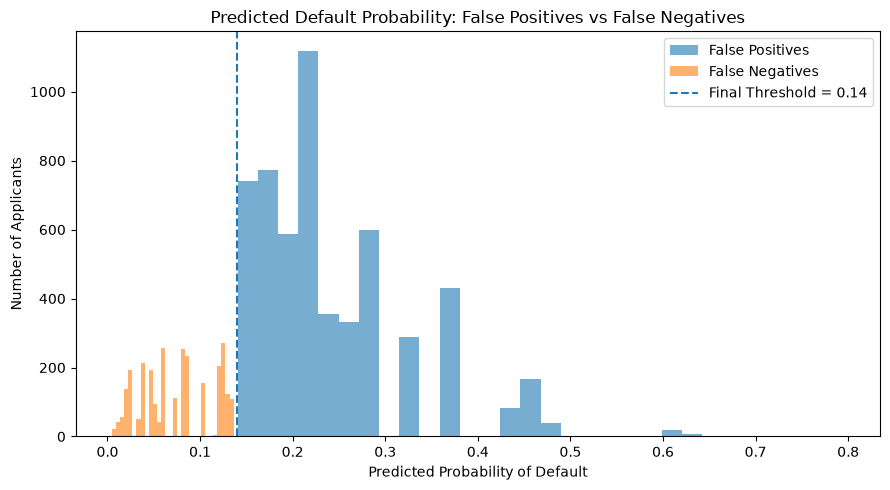

In [35]:


plt.figure(figsize=(9, 5))

plt.hist(
    false_positives["Predicted_Probability"],
    bins=30,
    alpha=0.6,
    label="False Positives"
)

plt.hist(
    false_negatives["Predicted_Probability"],
    bins=30,
    alpha=0.6,
    label="False Negatives"
)

plt.axvline(
    FINAL_THRESHOLD,
    linestyle="--",
    label=f"Final Threshold = {FINAL_THRESHOLD:.2f}"
)

plt.xlabel("Predicted Probability of Default")
plt.ylabel("Number of Applicants")
plt.title("Predicted Default Probability: False Positives vs False Negatives")
plt.legend()
plt.tight_layout()
plt.show()

In [36]:
# Final Business cost


FP_COST = final_model_package["false_positive_cost"]
FN_COST = final_model_package["false_negative_cost"]
final_business_cost = (
    FP * FP_COST +
    FN * FN_COST
)

print("FINAL BUSINESS COST")
print("=" * 80)

print(f"False Positive Cost: {FP_COST}")
print(f"False Negative Cost: {FN_COST}")

print(f"False Positives: {FP}")
print(f"False Negatives: {FN}")

print(f"\nFinal Business Cost: {final_business_cost:,.2f}")

FINAL BUSINESS COST
False Positive Cost: 1
False Negative Cost: 5
False Positives: 5545
False Negatives: 2767

Final Business Cost: 19,380.00




The final model uses a business cost of **1** for each False Positive and **5** for each False Negative. This reflects the assumption that incorrectly approving a customer who later defaults is **five times more costly** than incorrectly flagging a customer who would not have defaulted.

At the selected threshold of **0.14**, the model produced **5,545 False Positives** and **2,767 False Negatives**. The total business cost is therefore:

**(5,545 × 1) + (2,767 × 5) = 19,380**

The **final business cost is 19,380 cost units** on the validation dataset. The majority of this cost comes from False Negatives because they carry the higher penalty. This supports the use of the **0.14 threshold**, which was selected because it produced the lowest overall business cost among the tested thresholds.

## 11. Update final model package

In [37]:


final_model_package["threshold"] = FINAL_THRESHOLD

final_model_package["accuracy"] = final_accuracy
final_model_package["precision"] = final_precision
final_model_package["recall"] = final_recall
final_model_package["f1_score"] = final_f1

final_model_package["false_positives"] = int(FP)
final_model_package["false_negatives"] = int(FN)
final_model_package["true_positives"] = int(TP)
final_model_package["true_negatives"] = int(TN)

final_model_package["total_cost"] = float(
    final_business_cost
)

print("MODEL PACKAGE UPDATED")
print("=" * 80)

print("Threshold:", final_model_package["threshold"])
print("Accuracy:", final_model_package["accuracy"])
print("Precision:", final_model_package["precision"])
print("Recall:", final_model_package["recall"])
print("F1-score:", final_model_package["f1_score"])
print("Total cost:", final_model_package["total_cost"])

MODEL PACKAGE UPDATED
Threshold: 0.14
Accuracy: 0.8648521210347463
Precision: 0.28386930130440396
Recall: 0.44269889224572007
F1-score: 0.34592382751022976
Total cost: 19380.0




The final model package has been successfully updated with the **optimal decision threshold of 0.14**. This ensures that the saved model uses the same threshold identified through the business-cost analysis when making future credit-risk predictions.

At this threshold, the model achieved an **accuracy of 86.49%**, **precision of 28.39%**, **recall of 44.27%**, and an **F1-score of 34.59%** on the validation set. The model also achieved a **total business cost of 19,380**, which is the lowest cost identified during the threshold analysis.

Overall, the updated package now contains the final decision threshold and associated model configuration, making it ready for the next stages of **model verification, SHAP interpretation, and deployment in the credit-risk application**.

## 12. Saving the model

In [38]:
# Save final Model Package


joblib.dump(
    final_model_package,
    MODEL_PATH
)

print("FINAL MODEL PACKAGE SAVED")
print("=" * 80)
print("Saved to:", MODEL_PATH.resolve())

FINAL MODEL PACKAGE SAVED
Saved to: C:\Users\User\Desktop\final project\output\final_credit_risk_model.pkl


In [39]:
# ============================================================
# VERIFY FINAL SAVED MODEL
# ============================================================

verified_package = joblib.load(MODEL_PATH)

print("FINAL MODEL PACKAGE VERIFIED")
print("=" * 80)

print("Model:", verified_package["model_name"])
print("Calibration:", verified_package["calibration_method"])
print("Threshold:", verified_package["threshold"])
print("Training columns:", len(verified_package["training_columns"]))
print("Categorical columns:", len(verified_package["categorical_columns"]))
print("Total business cost:", verified_package["total_cost"])

FINAL MODEL PACKAGE VERIFIED
Model: Tuned Class-Weighted CatBoost
Calibration: Isotonic
Threshold: 0.14
Training columns: 842
Categorical columns: 0
Total business cost: 19380.0




The final model package has been successfully verified. The selected model is the **Tuned Class-Weighted CatBoost**, with **Isotonic calibration** applied to improve the reliability of its predicted probabilities.

The model uses a **decision threshold of 0.14** and expects exactly **842 training features**. The **categorical columns are 0**, confirming that all features supplied to the final model are already numerically encoded and ready for prediction.

The verified model has a **total business cost of 19,380** on the validation set. This confirms that the saved model package contains the intended model, calibration method, feature structure, and optimized threshold. The model is therefore ready for the **final interpretability and deployment stages**.

## 13. SHAP (SHapley Additive exPlanations) Analysis



Given the model's performance and the number of misclassifications, it is important to investigate **why the model is making incorrect predictions**. Therefore, a SHAP analysis will be conducted to understand which features are influencing the model's decisions and whether certain features are contributing to false positives and false negatives. This will help identify the main factors behind the model's predictions, assess whether the model is learning meaningful patterns, and provide greater transparency into its credit-risk decisions.

### A. SHAP Explainer for final model

In [40]:


# Use a sample to keep SHAP computation manageable
SHAP_SAMPLE_SIZE = 2000

X_shap = X_valid_model.sample(
    n=min(SHAP_SAMPLE_SIZE, len(X_valid_model)),
    random_state=42
)

print("SHAP DATA PREPARED")
print("=" * 80)

print("SHAP sample shape:", X_shap.shape)
print("Model features:", len(TRAINING_COLUMNS))

SHAP DATA PREPARED
SHAP sample shape: (2000, 842)
Model features: 842




This code prepares a **2,000-row sample** from the validation dataset for SHAP analysis. Instead of calculating SHAP values for all **61,503 validation observations**, the code randomly selects 2,000 observations using `random_state=42` so that the results are reproducible while keeping the computation manageable.

The output shows that the SHAP sample contains **2,000 observations and 842 features**, exactly matching the **842 features expected by the final CatBoost model**. This confirms that the data is correctly aligned and ready for the next step, where SHAP values will be calculated to explain **which features influence the model's credit-risk predictions and in which direction**.

### B. Create a SHAP Explainer

In [41]:


explainer = shap.TreeExplainer(
    final_model
)

print("SHAP EXPLAINER CREATED")
print("=" * 80)

print("Explainer type:", type(explainer).__name__)

SHAP EXPLAINER CREATED
Explainer type: TreeExplainer




**SHAP TreeExplainer** is used to explain how the final CatBoost model makes its predictions. Since CatBoost is a tree-based model, TreeExplainer efficiently calculates the contribution of each feature to the model's predicted credit risk.



### C. Calculate SHAP Values

In [42]:


shap_values = explainer.shap_values(
    X_shap
)

print("SHAP VALUES CALCULATED")
print("=" * 80)

print("SHAP values shape:", np.array(shap_values).shape)
print("SHAP sample shape:", X_shap.shape)

SHAP VALUES CALCULATED
SHAP values shape: (2000, 842)
SHAP sample shape: (2000, 842)




The SHAP values were successfully calculated for the **2,000 validation observations** using all **842 model features**. Each SHAP value represents the contribution of a specific feature to the model's prediction, showing whether that feature pushes the predicted default risk higher or lower and by how much.

The output confirms that the SHAP values have the shape **(2,000, 842)**, matching the SHAP sample and the model's 842 expected features. This means the SHAP analysis is correctly aligned with the final model and is ready for identifying the **most influential features and their direction of impact on default risk**.

### D. SHAP Global Feature Importance

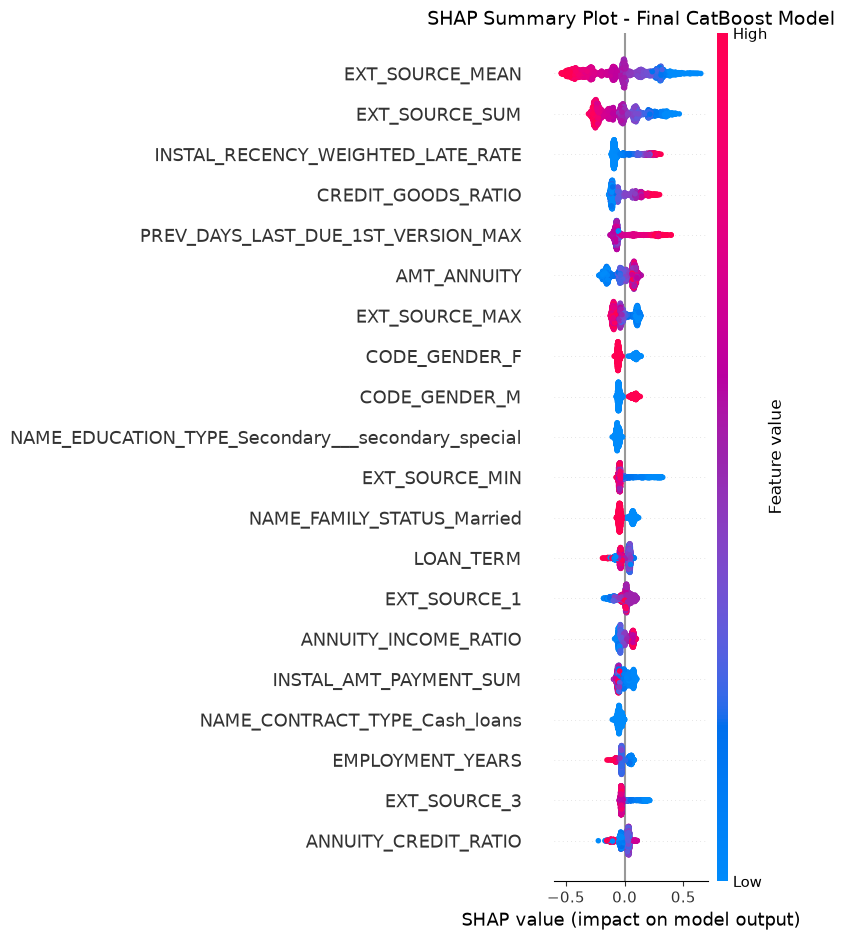

In [43]:
# SHAP Summary plot


plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_shap,
    max_display=20,
    show=False
)

plt.title(
    "SHAP Summary Plot - Final CatBoost Model",
    fontsize=14
)

plt.tight_layout()
plt.show()

## SHAP Analysis

The global SHAP ranking shows that the model is primarily driven by **external credit scores, repayment behaviour, and loan-structure features**. The **EXT_SOURCE_MEAN, EXT_SOURCE_SUM, and EXT_SOURCE_MAX** features are among the strongest predictors. Their SHAP relationships show a clear negative pattern: as external credit scores increase, SHAP values decrease, meaning **higher external credit scores are associated with lower predicted default risk**. This is an economically sensible relationship and provides a useful sanity check that the model has learned a meaningful pattern.

**INSTAL_RECENCY_WEIGHTED_LATE_RATE** is another important predictor. The SHAP values increase when recent late-payment behaviour becomes present, indicating that customers with recent repayment difficulties are assigned higher default risk. However, the effect begins to level off at higher late-payment rates, suggesting that once significant repayment problems are detected, additional lateness contributes less additional risk.

**CREDIT_GOODS_RATIO** also shows an important non-linear relationship. The SHAP impact remains relatively small when the credit amount is close to the goods price, but increases when the credit amount becomes substantially higher than the goods price. This suggests that greater levels of financing relative to the value of the goods are associated with higher predicted default risk.

Other features, including **gender, education, family status, annuity, employment years, and loan term**, also contribute to the model but have smaller overall effects compared with the external credit scores and repayment-related features.

### Overall Interpretation

Overall, the SHAP analysis indicates that the model's predictions are mainly driven by **external creditworthiness, previous repayment behaviour, and loan affordability/structure**. These relationships are generally consistent with expected credit-risk behaviour, which increases confidence in the model's interpretability. However, the model's **precision of approximately 28.4%** at the selected threshold means that many applicants flagged as high risk are actually non-defaulters. This represents the trade-off of using a lower threshold to improve **default recall to approximately 44.3%**, particularly because the business cost of a missed defaulter was set five times higher than the cost of a false positive.

In [44]:
# SHAP Feature importance and Direction


shap_direction_summary = pd.DataFrame({
    "Feature": TRAINING_COLUMNS,
    "Mean_Abs_SHAP": np.abs(shap_values).mean(axis=0),
    "Mean_SHAP": shap_values.mean(axis=0)
})

# Add direction based on average SHAP contribution
shap_direction_summary["Direction"] = np.where(
    shap_direction_summary["Mean_SHAP"] > 0,
    "Higher default risk",
    "Lower default risk"
)

# Rank features by overall importance
shap_direction_summary = (
    shap_direction_summary
    .sort_values(
        "Mean_Abs_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

print("TOP 20 SHAP FEATURES — IMPORTANCE AND DIRECTION")
print("=" * 100)

print(
    shap_direction_summary
    .head(20)
    .to_string(index=False)
)

TOP 20 SHAP FEATURES — IMPORTANCE AND DIRECTION
                                          Feature  Mean_Abs_SHAP  Mean_SHAP           Direction
                                  EXT_SOURCE_MEAN       0.237090  -0.050462  Lower default risk
                                   EXT_SOURCE_SUM       0.167254  -0.036837  Lower default risk
                INSTAL_RECENCY_WEIGHTED_LATE_RATE       0.107949  -0.008769  Lower default risk
                               CREDIT_GOODS_RATIO       0.101929  -0.009266  Lower default risk
               PREV_DAYS_LAST_DUE_1ST_VERSION_MAX       0.100191  -0.005393  Lower default risk
                                      AMT_ANNUITY       0.083049  -0.015847  Lower default risk
                                   EXT_SOURCE_MAX       0.073354  -0.014670  Lower default risk
                                    CODE_GENDER_F       0.067322  -0.007808  Lower default risk
                                    CODE_GENDER_M       0.060241  -0.007032  Lower defau


This table combines **feature importance** and **direction of influence**. `Mean_Abs_SHAP` shows how strongly a feature influences the model overall, while `Mean_SHAP` shows the average direction of that influence. A negative Mean SHAP indicates that, on average, the feature pushes predictions toward **lower default risk**, while a positive value indicates **higher default risk**.

The strongest overall feature is **EXT_SOURCE_MEAN**, with a Mean Absolute SHAP value of **0.2371** and a negative Mean SHAP of **-0.0505**, indicating that external credit information has a major influence and generally pushes predictions toward lower default risk. **EXT_SOURCE_SUM** is the second most influential feature and also has a negative overall direction. Other important features such as **INSTAL_RECENCY_WEIGHTED_LATE_RATE, CREDIT_GOODS_RATIO, PREV_DAYS_LAST_DUE_1ST_VERSION_MAX, and AMT_ANNUITY** also have negative average SHAP values in this dataset, meaning their overall contribution across the SHAP sample was toward lower predicted risk.

Most of the top features have negative Mean SHAP values, while **EXT_SOURCE_1** is the only feature in the top 20 with a positive average SHAP value (**0.0022**), indicating a small overall contribution toward higher default risk in this sample. However, the direction shown here is an **average effect** and should not be interpreted as meaning that every value of a feature always increases or decreases risk. The impact can vary depending on the feature's actual value and its interaction with other variables.

Overall, the results confirm that the model is primarily influenced by **external credit information, repayment behaviour, loan characteristics, and affordability measures**. The relatively large Mean Absolute SHAP values for the external-score features demonstrate that creditworthiness is the strongest driver of the model's predictions, while the smaller values for demographic and application features indicate a comparatively weaker overall influence.

### E. Shap Dependence Plot (Top Features)

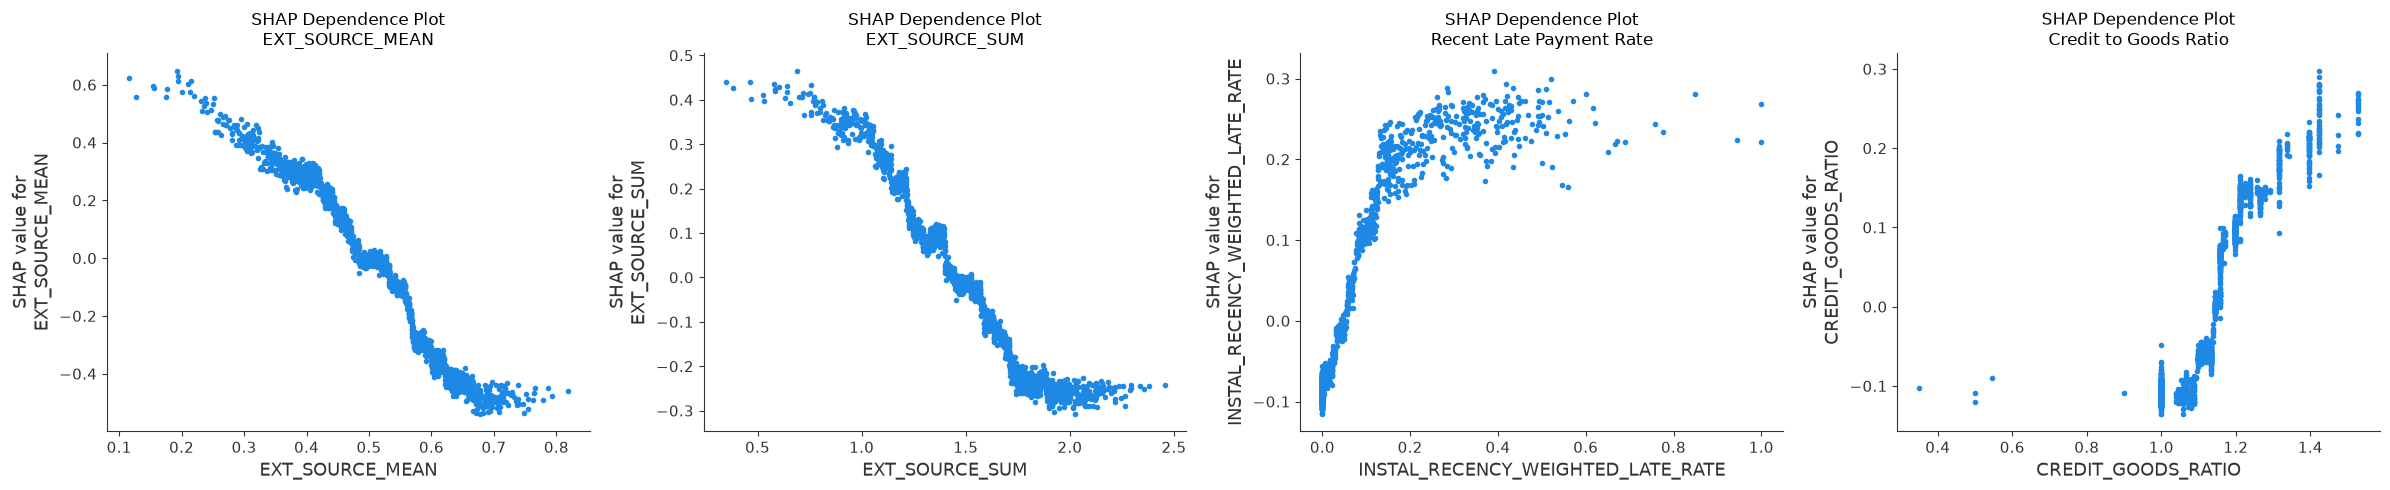

In [45]:


features_to_plot = [
    "EXT_SOURCE_MEAN",
    "EXT_SOURCE_SUM",
    "INSTAL_RECENCY_WEIGHTED_LATE_RATE",
    "CREDIT_GOODS_RATIO"
]

plot_titles = [
    "EXT_SOURCE_MEAN",
    "EXT_SOURCE_SUM",
    "Recent Late Payment Rate",
    "Credit to Goods Ratio"
]

fig, axes = plt.subplots(
    1,
    4,
    figsize=(24, 5)
)

for feature, title, ax in zip(
    features_to_plot,
    plot_titles,
    axes
):

    shap.dependence_plot(
        feature,
        shap_values,
        X_shap,
        interaction_index=None,
        show=False,
        ax=ax
    )

    ax.set_title(
        f"SHAP Dependence Plot\n{title}"
    )

plt.tight_layout()
plt.show()

## SHAP Dependence Plot Interpretation

### 1. EXT_SOURCE_MEAN

This is the **most important feature** in the model. When the external credit score is low, it increases the predicted default risk. As the score increases, the predicted default risk decreases. The strongest change happens around the middle range of the scores, meaning this feature is particularly useful for separating lower-risk and higher-risk applicants.

### 2. EXT_SOURCE_SUM

This feature shows a very similar pattern to `EXT_SOURCE_MEAN`. Higher external scores are associated with lower default risk, while lower scores are associated with higher risk. Because this feature is calculated from the same external scores, it provides similar information to `EXT_SOURCE_MEAN` rather than a completely different risk signal.

### 3. Recent Late Payment Rate

The model shows that **recent late payments are an important warning sign**. Applicants with little or no recent late-payment history generally have lower predicted risk. Once the late-payment rate becomes significant, the predicted risk increases sharply and then levels off. This suggests that the model is mainly interested in whether an applicant has a meaningful recent history of late payments rather than the exact amount of additional lateness.

### 4. Credit to Goods Ratio

When the credit amount is close to or below the value of the goods being financed, the feature has little negative impact on default risk. However, when the credit amount becomes noticeably higher than the goods value, the predicted default risk increases. This suggests that **over-financing is treated as a potential warning sign** by the model.

### Overall Interpretation

The four features show two different types of behaviour. **`EXT_SOURCE_MEAN` and `EXT_SOURCE_SUM` provide continuous signals**, where higher credit scores generally correspond to lower default risk. In contrast, **recent late-payment rate and credit-to-goods ratio behave more like warning triggers**, where risk increases significantly after certain levels are reached.

Overall, the SHAP analysis shows that the model relies heavily on **external creditworthiness and repayment behaviour**, while also considering whether the loan structure may indicate increased financial risk.

### F. SHAP Numerical Direction Analysis

In [46]:

features_to_analyze = [
    "EXT_SOURCE_MEAN",
    "EXT_SOURCE_SUM",
    "INSTAL_RECENCY_WEIGHTED_LATE_RATE",
    "CREDIT_GOODS_RATIO",
    "PREV_DAYS_LAST_DUE_1ST_VERSION_MAX",
    "AMT_ANNUITY",
    "EXT_SOURCE_MAX",
    "EXT_SOURCE_MIN",
    "LOAN_TERM",
    "ANNUITY_INCOME_RATIO",
    "INSTAL_AMT_PAYMENT_SUM",
    "EMPLOYMENT_YEARS",
    "EXT_SOURCE_1",
    "EXT_SOURCE_3",
    "ANNUITY_CREDIT_RATIO"
]

results = []

for feature in features_to_analyze:

    # Get feature position
    feature_index = X_shap.columns.get_loc(feature)

    # Feature values
    feature_values = X_shap[feature].values

    # Corresponding SHAP values
    feature_shap = shap_values[:, feature_index]

    # Remove missing values
    valid = ~pd.isna(feature_values)

    feature_values = feature_values[valid]
    feature_shap = feature_shap[valid]

    # Divide feature into three groups
    low_cutoff = np.percentile(feature_values, 33.33)
    high_cutoff = np.percentile(feature_values, 66.67)

    low_mask = feature_values <= low_cutoff

    medium_mask = (
        (feature_values > low_cutoff) &
        (feature_values <= high_cutoff)
    )

    high_mask = feature_values > high_cutoff

    results.append({
        "Feature": feature,

        "Low_Value_Mean_SHAP":
            feature_shap[low_mask].mean(),

        "Medium_Value_Mean_SHAP":
            feature_shap[medium_mask].mean(),

        "High_Value_Mean_SHAP":
            feature_shap[high_mask].mean()
    })

shap_value_groups = pd.DataFrame(results)

print("SHAP VALUE DIRECTION BY FEATURE LEVEL")
print("=" * 110)

print(
    shap_value_groups.to_string(index=False)
)

SHAP VALUE DIRECTION BY FEATURE LEVEL
                           Feature  Low_Value_Mean_SHAP  Medium_Value_Mean_SHAP  High_Value_Mean_SHAP
                   EXT_SOURCE_MEAN             0.273982               -0.048003             -0.377362
                    EXT_SOURCE_SUM             0.194457               -0.065177             -0.239834
 INSTAL_RECENCY_WEIGHTED_LATE_RATE            -0.089267               -0.079088              0.145451
                CREDIT_GOODS_RATIO            -0.107370               -0.041175              0.141396
PREV_DAYS_LAST_DUE_1ST_VERSION_MAX            -0.069210               -0.076697              0.129910
                       AMT_ANNUITY            -0.134792                0.003851              0.083670
                    EXT_SOURCE_MAX             0.086949               -0.035123             -0.095867
                    EXT_SOURCE_MIN             0.053297               -0.043465             -0.043650
                         LOAN_TERM          

## SHAP Value Direction by Feature Level

This analysis shows how the model's risk assessment changes when each important feature has **low, medium, or high values**. Positive SHAP values indicate that the feature pushes the prediction toward **higher default risk**, while negative SHAP values indicate **lower default risk**.

- **EXT_SOURCE_MEAN:** Low values have a positive SHAP value (**0.274**), increasing default risk. High values have a strongly negative value (**-0.377**), reducing default risk. This confirms that **higher external credit scores are associated with lower default risk**.

- **EXT_SOURCE_SUM:** The pattern is similar. Low values increase risk (**0.194**), while high values reduce risk (**-0.240**). This is consistent with the behaviour of the external credit scores.

- **INSTAL_RECENCY_WEIGHTED_LATE_RATE:** Low and medium values slightly reduce risk, while high values increase risk (**0.145**). This indicates that **significant recent late-payment behaviour is a warning sign**.

- **CREDIT_GOODS_RATIO:** Low values reduce risk (**-0.107**), while high values increase risk (**0.141**). This suggests that **borrowing substantially more than the value of the goods is associated with higher default risk**.

- **PREV_DAYS_LAST_DUE_1ST_VERSION_MAX:** Low and medium values are associated with lower risk, while high values increase risk (**0.130**), indicating that certain patterns in previous loan repayment behaviour can increase predicted risk.

- **AMT_ANNUITY:** Low values are associated with lower risk (**-0.135**), while high values increase risk (**0.084**). This suggests that higher repayment obligations can contribute to higher predicted risk.

- **ANNUITY_INCOME_RATIO:** Low values reduce risk, while high values increase risk. This indicates that **larger repayment obligations relative to income can be a warning sign**.

- **EMPLOYMENT_YEARS:** Higher employment years generally have a negative SHAP value, suggesting that **longer employment history is associated with lower predicted default risk**.

### Overall Interpretation

The feature-level analysis confirms that the model responds differently depending on the actual value of a feature. **Low external credit scores, high recent late-payment rates, high credit-to-goods ratios, and high repayment obligations generally push predictions toward higher default risk**, while stronger external scores and more stable financial characteristics tend to reduce predicted risk.

This analysis is useful because it goes beyond simply identifying the most important features. It shows **how different levels of those features influence the model's credit-risk decision**.

### G. Feature importance plot

In [47]:


# Calculate mean absolute SHAP value for each feature
shap_importance = pd.DataFrame({
    "Feature": X_shap.columns,
    "Mean_Abs_SHAP": np.abs(shap_values).mean(axis=0)
})

# Sort features by importance
shap_importance = shap_importance.sort_values(
    "Mean_Abs_SHAP",
    ascending=False
)

print("TOP 20 SHAP FEATURES")
print("=" * 80)

display(shap_importance.head(20))

TOP 20 SHAP FEATURES


,Feature,Mean_Abs_SHAP
730,EXT_SOURCE_MEAN,0.237090
734,EXT_SOURCE_SUM,0.167254
591,INSTAL_RECENCY_WEIGHTED_LATE_RATE,0.107949
717,CREDIT_GOODS_RATIO,0.101929
386,PREV_DAYS_LAST_DUE_1ST_VERSION_MAX,0.100191
3,AMT_ANNUITY,0.083049
731,EXT_SOURCE_MAX,0.073354
741,CODE_GENDER_F,0.067322
742,CODE_GENDER_M,0.060241
768,NAME_EDUCATION_TYPE_Secondary___secondary_special,0.059217


## 14. Final Model Performance summary

In [48]:


final_model_summary = pd.DataFrame({
    "Metric": [
        "Model",
        "Calibration Method",
        "Decision Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "Average Precision",
        "Brier Score",
        "Business Cost"
    ],
    
    "Value": [
        final_model_package["model_name"],
        final_model_package["calibration_method"],
        FINAL_THRESHOLD,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        average_precision,
        brier,
        total_business_cost
    ]
})

display(final_model_summary)

,Metric,Value
0,Model,Tuned Class-Weighted CatBoost
1,Calibration Method,Isotonic
2,Decision Threshold,0.14
3,Accuracy,0.864852
4,Precision,0.283869
5,Recall,0.442699
6,F1-Score,0.345924
7,ROC-AUC,0.783764
8,Average Precision,0.275057
9,Brier Score,0.065888





The final model is a **Tuned Class-Weighted CatBoost** model using **Isotonic calibration** and a **0.14 decision threshold**. It achieved **86.49% accuracy**, **44.27% recall**, and **28.39% precision**. The recall means the model correctly identified about 44% of actual defaulters, while the precision shows that about 28% of applicants flagged as defaulters were actually defaulters.

The **ROC-AUC of 0.7838** indicates good ability to distinguish between defaulters and non-defaulters, while the **Brier Score of 0.0659** indicates reasonably well-calibrated probability predictions. Most importantly, the selected threshold produced a **business cost of 19,380**, which was the lowest cost identified during threshold analysis. Overall, the model prioritizes identifying more potential defaulters because missing a genuine defaulter is considered five times more costly than incorrectly flagging a non-defaulter.

## 15. Business Impact Summary

In [49]:


tn, fp, fn, tp = confusion_matrix(
    y_valid,
    final_predictions
).ravel()

business_summary = pd.DataFrame({
    "Outcome": [
        "Correctly identified non-defaulters",
        "Incorrectly flagged non-defaulters",
        "Missed defaulters",
        "Correctly identified defaulters"
    ],

    "Number of Applicants": [
        tn,
        fp,
        fn,
        tp
    ],

    "Business Meaning": [
        "Applicants correctly identified as low risk",
        "Low-risk applicants incorrectly flagged as risky",
        "Risky applicants incorrectly classified as low risk",
        "Risky applicants correctly identified"
    ]
})

display(business_summary)

,Outcome,Number of Applicants,Business Meaning
0,Correctly identified non-defaulters,50993,Applicants correctly identified as low risk
1,Incorrectly flagged non-defaulters,5545,Low-risk applicants incorrectly flagged as risky
2,Missed defaulters,2767,Risky applicants incorrectly classified as low...
3,Correctly identified defaulters,2198,Risky applicants correctly identified


The output shows that 50,993 non-defaulters were correctly identified as low risk, while 5,545 non-defaulters were incorrectly flagged as risky. However, the model missed 2,767 actual defaulters, classifying them as low risk, while correctly identifying 2,198 actual defaulters as risky.

These results are consistent with the final confusion matrix of TN = 50,993, FP = 5,545, FN = 2,767, and TP = 2,198. Therefore, the final business summary accurately reflects the model's performance on the validation dataset.

## 16.  Final Catboost Business summary

In [ ]:

catboost_business_summary = pd.DataFrame({
    
    "Metric": [
        "Model",
        "Calibration",
        "Decision Threshold",
        "ROC-AUC",
        "Average Precision",
        "Brier Score",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "False Positives",
        "False Negatives",
        "Total Business Cost"
    ],

    "Value": [
        final_model_package["model_name"],
        final_model_package["calibration_method"],
        FINAL_THRESHOLD,
        roc_auc,
        average_precision,
        brier,
        accuracy,
        precision,
        recall,
        f1,
        fp,
        fn,
        total_business_cost
    ]
})

display(catboost_business_summary)

,Metric,Value
0,Model,Tuned Class-Weighted CatBoost
1,Calibration,Isotonic
2,Decision Threshold,0.14
3,ROC-AUC,0.783764
4,Average Precision,0.275057
5,Brier Score,0.065888
6,Accuracy,0.864852
7,Precision,0.283869
8,Recall,0.442699
9,F1-Score,0.345924


In [55]:


OUTPUT_DIR = Path("output")

MODEL_PATH = OUTPUT_DIR / "final_credit_risk_model.pkl"

final_model_package = joblib.load(MODEL_PATH)

print("MODEL LOADED SUCCESSFULLY")
print("=" * 80)
print(final_model_package.keys())

MODEL LOADED SUCCESSFULLY
dict_keys(['model_name', 'model', 'calibrator', 'calibration_method', 'threshold', 'false_positive_cost', 'false_negative_cost', 'selection_criteria', 'total_cost', 'accuracy', 'precision', 'recall', 'f1_score', 'false_positives', 'false_negatives', 'true_positives', 'true_negatives', 'training_columns', 'categorical_columns'])


In [56]:
print("MODEL:", final_model_package["model_name"])
print("CALIBRATION:", final_model_package["calibration_method"])
print("THRESHOLD:", final_model_package["threshold"])
print("TOTAL BUSINESS COST:", final_model_package["total_cost"])

MODEL: Tuned Class-Weighted CatBoost
CALIBRATION: Isotonic
THRESHOLD: 0.14
TOTAL BUSINESS COST: 19380.0


In [57]:
print("NUMBER OF TRAINING COLUMNS:", len(final_model_package["training_columns"]))

print(
    "NUMBER OF CATEGORICAL COLUMNS:",
    len(final_model_package["categorical_columns"])
)

print("\nCATEGORICAL COLUMNS:")
print(final_model_package["categorical_columns"])

NUMBER OF TRAINING COLUMNS: 842
NUMBER OF CATEGORICAL COLUMNS: 0

CATEGORICAL COLUMNS:
[]


In [58]:
print("FIRST 30 TRAINING COLUMNS:")
print(final_model_package["training_columns"][:30])

print("\nLAST 20 TRAINING COLUMNS:")
print(final_model_package["training_columns"][-20:])

FIRST 30 TRAINING COLUMNS:
['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

LAST 20 TRAINING COLUMNS:
['FONDKAPREMONT_MODE_Missing', 'FONDKAPREMONT_MODE_not_specified', 'FONDKAPREMONT_MODE_org_spec_account', 'FONDKAPREMONT_MODE_reg_oper_account', 'FONDKAPREMONT_MODE_reg_oper_spec_account', 'HOUSETYPE_MODE_Missing', 'HOUSETYPE_MODE_block_of_flats', 'HOUSETYPE_MODE_specific_housing', 'HOUSETYPE_MODE_terraced_house', 'WALLSMATER

In [59]:
print("MODEL TYPE:")
print(type(final_model_package["model"]))

print("\nCALIBRATOR TYPE:")
print(type(final_model_package["calibrator"]))

print("\nNUMBER OF FEATURES EXPECTED:")
print(final_model_package["model"].n_features_in_)

MODEL TYPE:
<class 'catboost.core.CatBoostClassifier'>

CALIBRATOR TYPE:
<class 'sklearn.isotonic.IsotonicRegression'>

NUMBER OF FEATURES EXPECTED:
0


# Final Model Summary

After comparing multiple classification models, addressing class imbalance, performing cross-validation, class weighting, hyperparameter tuning, probability calibration, threshold analysis, business-cost analysis, and SHAP-based explainability, the final model selected for the credit risk prediction task was a **Tuned Class-Weighted CatBoost classifier**.

CatBoost was selected as the final model after the model comparison and tuning process. Class weighting was applied to give greater importance to the minority class (defaulters), helping the model focus more on identifying customers who are likely to default.

The final model was calibrated using **Isotonic calibration** to improve the reliability of its predicted probabilities. Business-cost analysis was then used to determine the most appropriate decision threshold. The analysis identified **0.14** as the threshold that produced the lowest total business cost on the validation dataset.

At the final threshold of **0.14**, the model achieved the following validation performance:

- **Accuracy:** 86.49%
- **Defaulter Precision:** 28.39%
- **Defaulter Recall:** 44.27%
- **Defaulter F1-score:** 34.59%
- **ROC-AUC:** 0.7838
- **Average Precision:** 0.2751
- **Brier Score:** 0.0659
- **Total Business Cost:** 19,380

The model correctly identified **2,198 out of 4,965 actual defaulters**, giving a defaulter recall of approximately **44.3%**. However, its precision of **28.4%** shows that a considerable number of applicants flagged as high risk were actually non-defaulters. This reflects the trade-off made when selecting the threshold based on the assumption that a false negative is five times more costly than a false positive.

The final model was also investigated using **SHAP analysis** to understand which features were driving its predictions. The analysis showed that external credit-score features, particularly `EXT_SOURCE_MEAN` and `EXT_SOURCE_SUM`, were among the strongest predictors, followed by repayment behaviour and loan-structure features.

The final calibrated model and its decision threshold were saved as part of the model package, allowing the same preprocessing, calibration, and prediction logic to be used in the Streamlit application. Predictions for the unseen test dataset were also generated and saved in `test_predictions.csv`.

# Key Findings

## 1. Accuracy was not a reliable measure of model performance

The dataset was highly imbalanced, with defaulters representing only about **8% of applicants**. As a result, a model could achieve high accuracy simply by predicting most customers as non-defaulters while performing poorly at identifying actual defaulters.

Therefore, the evaluation focused on **precision, recall, F1-score, ROC-AUC, Average Precision, Brier Score, and business cost**, rather than relying on accuracy alone.

---

## 2. CatBoost provided the final modelling solution

Several classification models were evaluated, including Logistic Regression, XGBoost, LightGBM, CatBoost, and Random Forest.

After model comparison, class weighting, hyperparameter tuning, calibration, and threshold analysis, **Tuned Class-Weighted CatBoost** was selected as the final model.

The final model achieved a **ROC-AUC of 0.7838**, showing that it has a reasonable ability to distinguish between defaulters and non-defaulters.

---

## 3. Class weighting helped address the class imbalance

Because defaulters were a minority class, the model could otherwise focus heavily on the much larger non-defaulter class.

Class weighting increased the importance of defaulters during model training. This allowed the model to pay greater attention to the minority class and improve its ability to identify customers who are likely to default.

The improvement in minority-class detection comes with a trade-off: more non-defaulters may also be incorrectly flagged as high risk.

---

## 4. Probability calibration improved the model's risk estimates

The final CatBoost predictions were passed through **Isotonic calibration** before applying the classification threshold.

Calibration was used to make the predicted probabilities more representative of the actual likelihood of default.

The final calibrated probabilities had a **Brier Score of 0.0659**, indicating reasonably good probability accuracy, where a lower Brier Score represents better calibration.

---

## 5. The decision threshold was selected using business cost

Instead of automatically using the standard **0.50 threshold**, several thresholds were tested between 0.05 and 0.50.

The analysis identified **0.14** as the threshold with the lowest total business cost.

At this threshold:

- **False Positives:** 5,545
- **False Negatives:** 2,767
- **False Positive Cost:** 1 each
- **False Negative Cost:** 5 each
- **Total Business Cost:** 19,380

This means the threshold was selected based on the business assumption that **missing a genuine defaulter is five times more costly than incorrectly flagging a non-defaulter**.

---

## 6. The model performs better for non-defaulters than defaulters

The classification report showed:

- **Non-defaulter precision:** 95%
- **Non-defaulter recall:** 90%
- **Defaulter precision:** 28%
- **Defaulter recall:** 44%

This shows that the model is much stronger at identifying non-defaulters than defaulters.

However, because defaulters are the more important class from a credit-risk perspective, the **44% defaulter recall** is particularly important. The model successfully identifies a substantial portion of actual defaulters while accepting some false-positive predictions.

---

## 7. SHAP analysis provided model explainability

SHAP analysis was conducted to investigate how the model makes its predictions and to understand the factors contributing to model decisions.

The most influential features included:

- `EXT_SOURCE_MEAN`
- `EXT_SOURCE_SUM`
- `INSTAL_RECENCY_WEIGHTED_LATE_RATE`
- `CREDIT_GOODS_RATIO`
- `PREV_DAYS_LAST_DUE_1ST_VERSION_MAX`
- `AMT_ANNUITY`

The external credit-score features were particularly influential. Higher external scores generally pushed the model toward **lower default risk**, while weaker scores pushed predictions toward **higher default risk**.

Recent late-payment behaviour and the credit-to-goods ratio also showed meaningful influence on predicted risk.

This provides evidence that the model is using economically meaningful credit-risk information rather than relying entirely on arbitrary patterns.

---

# Business Recommendations

## 1. Use the model as a decision-support tool

The model should not be used as the sole basis for automatically approving or rejecting loans.

Instead, it can be used to identify applicants who require different levels of credit assessment.

For example:

- **Low-risk applicants:** Standard assessment
- **Medium-risk applicants:** Additional verification
- **High-risk applicants:** Enhanced credit review

This allows the model to support human decision-making rather than completely replacing it.

---

## 2. Use the 0.14 threshold according to the defined business costs

The analysis identified **0.14** as the minimum-cost threshold under the project's assumed cost structure.

The business should periodically review this threshold because the actual costs of false positives and false negatives may differ from the assumptions used in this project.

If missing a defaulter becomes more expensive, a lower threshold may be appropriate. If false positives become more expensive, a higher threshold may be considered.

---

## 3. Do not automatically reject all high-risk predictions

The model has a defaulter precision of approximately **28%**, meaning that many applicants flagged as high risk are actually non-defaulters.

Therefore, a high-risk prediction should ideally trigger **additional review rather than automatic rejection**.

Additional checks could include income verification, existing credit obligations, repayment history, and supporting documentation.

---

## 4. Use SHAP explanations to support credit reviews

SHAP can be used to provide understandable reasons behind individual predictions.

For example, if an applicant is classified as high risk, the system can identify influential factors such as:

- Low external credit scores
- Recent late-payment behaviour
- High credit-to-goods ratio
- Other important repayment or loan characteristics

This can help credit officers understand and review the model's decision.

---

## 5. Monitor model performance after deployment

The model should be continuously monitored after deployment.

Important metrics to monitor include:

- Defaulter recall
- Precision
- False-negative rate
- ROC-AUC
- Average Precision
- Brier Score
- Business cost

Changes in economic conditions, customer behaviour, or lending policies may cause the model's performance to change over time.

---

## 6. Monitor performance across demographic groups

The fairness analysis showed that model performance varies across gender and age groups.

These differences should be monitored regularly using metrics such as **defaulter recall and false-negative rate**.

Differences in performance do not automatically prove that the model is biased, but they should be investigated to ensure that the model performs reasonably across different customer groups.

# Limitations

## 1. The model does not identify every defaulter

At the final threshold of 0.14, the model achieved a defaulter recall of **44.27%**.

This means that approximately **56% of actual defaulters were still missed** by the model.

Therefore, the model should not be considered a perfect predictor of default.

---

## 2. Defaulter precision is relatively low

The model achieved a defaulter precision of **28.39%**.

This means that many applicants classified as high risk were actually non-defaulters.

This creates false positives and means that the model's high-risk predictions should be treated as risk signals rather than definite evidence that an applicant will default.

---

## 3. Threshold selection involves a trade-off

The threshold of **0.14** minimizes business cost under the assumed **1:5 false-positive-to-false-negative cost ratio**.

Changing the threshold would change the balance between precision, recall, false positives, and false negatives.

Therefore, the optimal threshold may change if the actual business costs change.

---

## 4. Validation performance may not represent future performance

The model was evaluated using historical validation data.

Future applicants may have different financial circumstances and behaviours.

Changes in economic conditions, employment, interest rates, customer behaviour, or lending policies could therefore affect the model's future performance.

---

## 5. Fairness differences require further investigation

The fairness analysis identified differences in defaulter recall across gender and age groups.

These differences should be investigated further before using the model in a real lending environment.

Monitoring should continue after deployment to identify whether these performance differences remain stable or increase over time.

---

## 6. SHAP explanations do not establish causation

SHAP identifies the features that influence the model's predictions.

However, these relationships should not be interpreted as proof that a particular feature directly causes a customer to default.

SHAP explains the model's learned patterns rather than establishing causal relationships.

---

## 7. The unseen test dataset cannot be used to calculate final performance

The final model was used to generate predictions for the unseen test dataset.

However, because the actual default outcomes are not available for these applicants, metrics such as accuracy, precision, recall, and F1-score cannot be calculated for the test predictions.

The test predictions should therefore be treated as **model outputs for future evaluation or submission**, rather than evidence of real-world model performance.